After we complted the preprocessing next comes the segmentation and sampling of the new data which we got


In [ ]:
#importing the required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from statsmodels.tsa.stattools import acf
import seaborn as sns


Extracted 10488 segments with 0.5 threshold
Total samples extracted: 540278
Inspecting one sample:

             x            y          z  velocityX  velocityY  velocityZ  \
0  1476.600000  2000.500000 -66.300000     -39.25      39.26       5.98   
1  1475.291544  2001.808583 -66.100702     -29.90      29.90      -1.43   
2  1474.606825  2002.493429 -66.395073     -23.87      20.87     -13.49   
3  1473.700000  2003.200000 -67.000000     -34.82      21.22     -18.15   
4  1472.285382  2003.908307 -67.604993     -40.35      25.34     -14.95   

   tort_Xy  tort_Xz  
0      0.0     0.00  
1      1.0     1.04  
2      1.0     1.00  
3      1.0     1.00  
4      1.0     1.00  


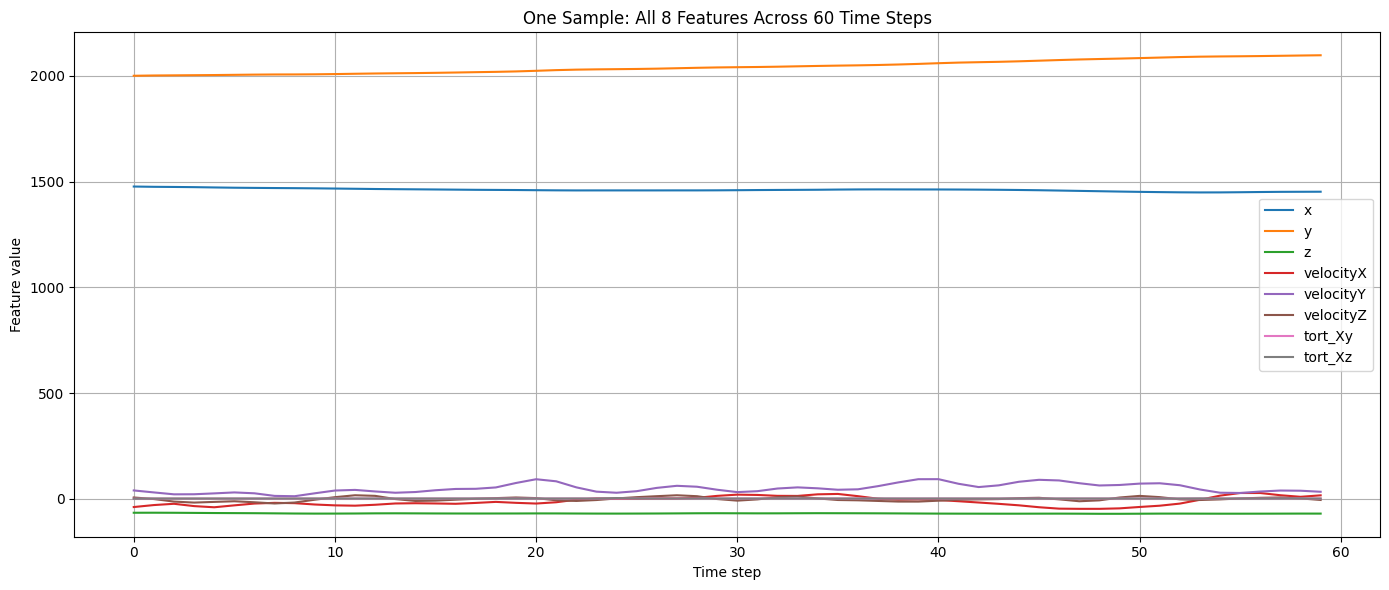

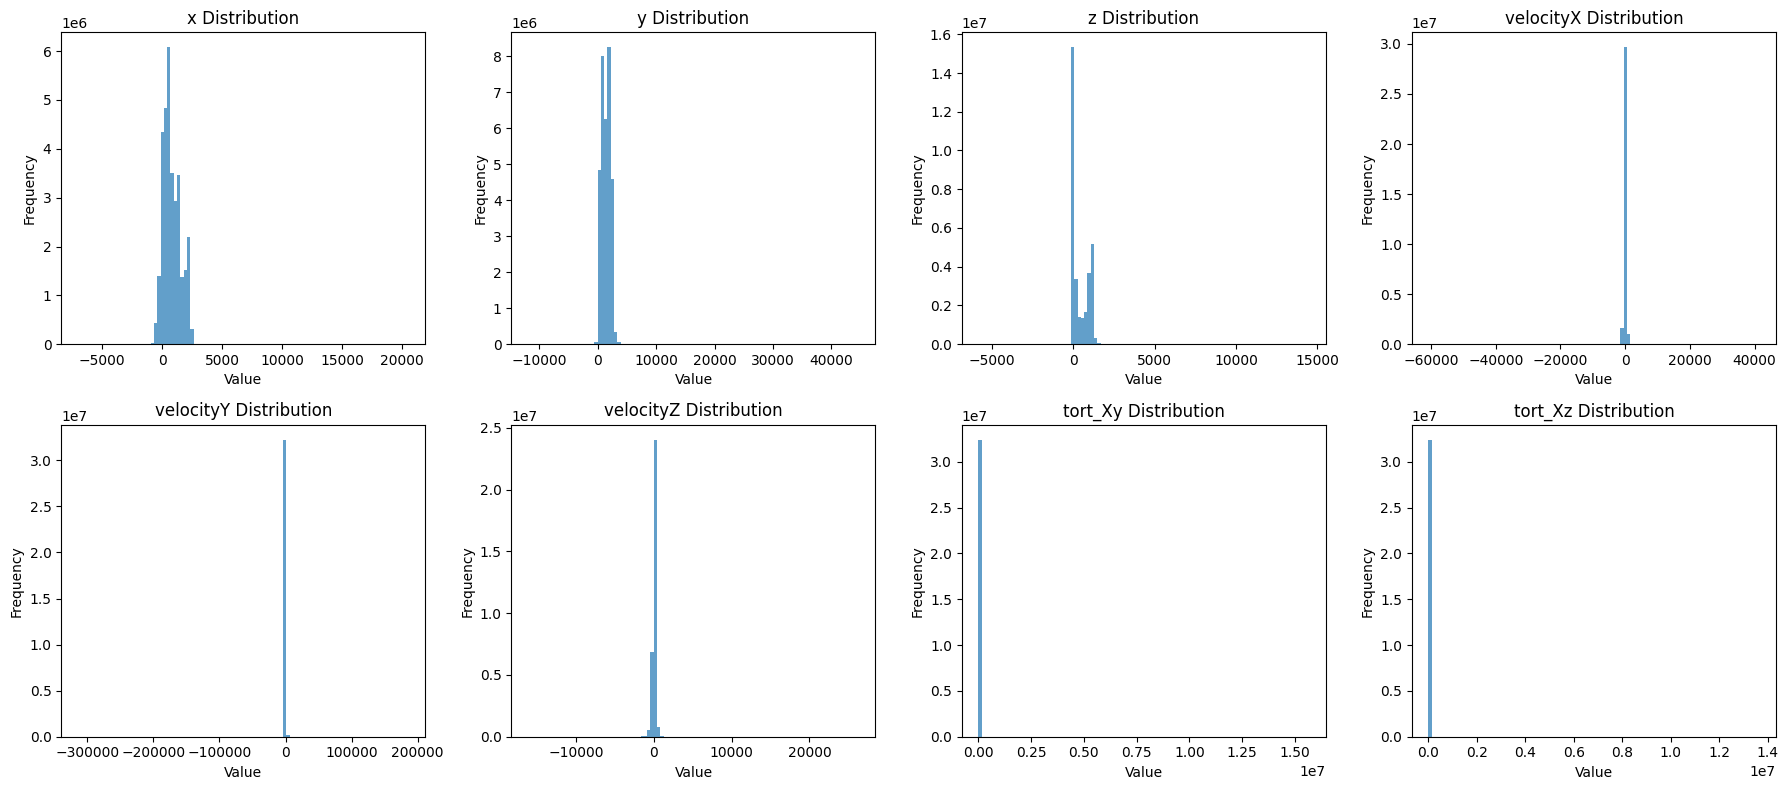

Saved normalization stats to bee_norm_stats.pkl
x: mean = 779.6618, std = 706.5695
y: mean = 1416.7146, std = 733.1523
z: mean = 380.3618, std = 496.5605
velocityX: mean = -0.8922, std = 285.2440
velocityY: mean = -1.9907, std = 379.0153
velocityZ: mean = 1.2740, std = 194.2895
tort_Xy: mean = 4.9515, std = 6623.6871
tort_Xz: mean = 4.4630, std = 5693.8145
Saved tensor shape: torch.Size([540278, 8, 60])


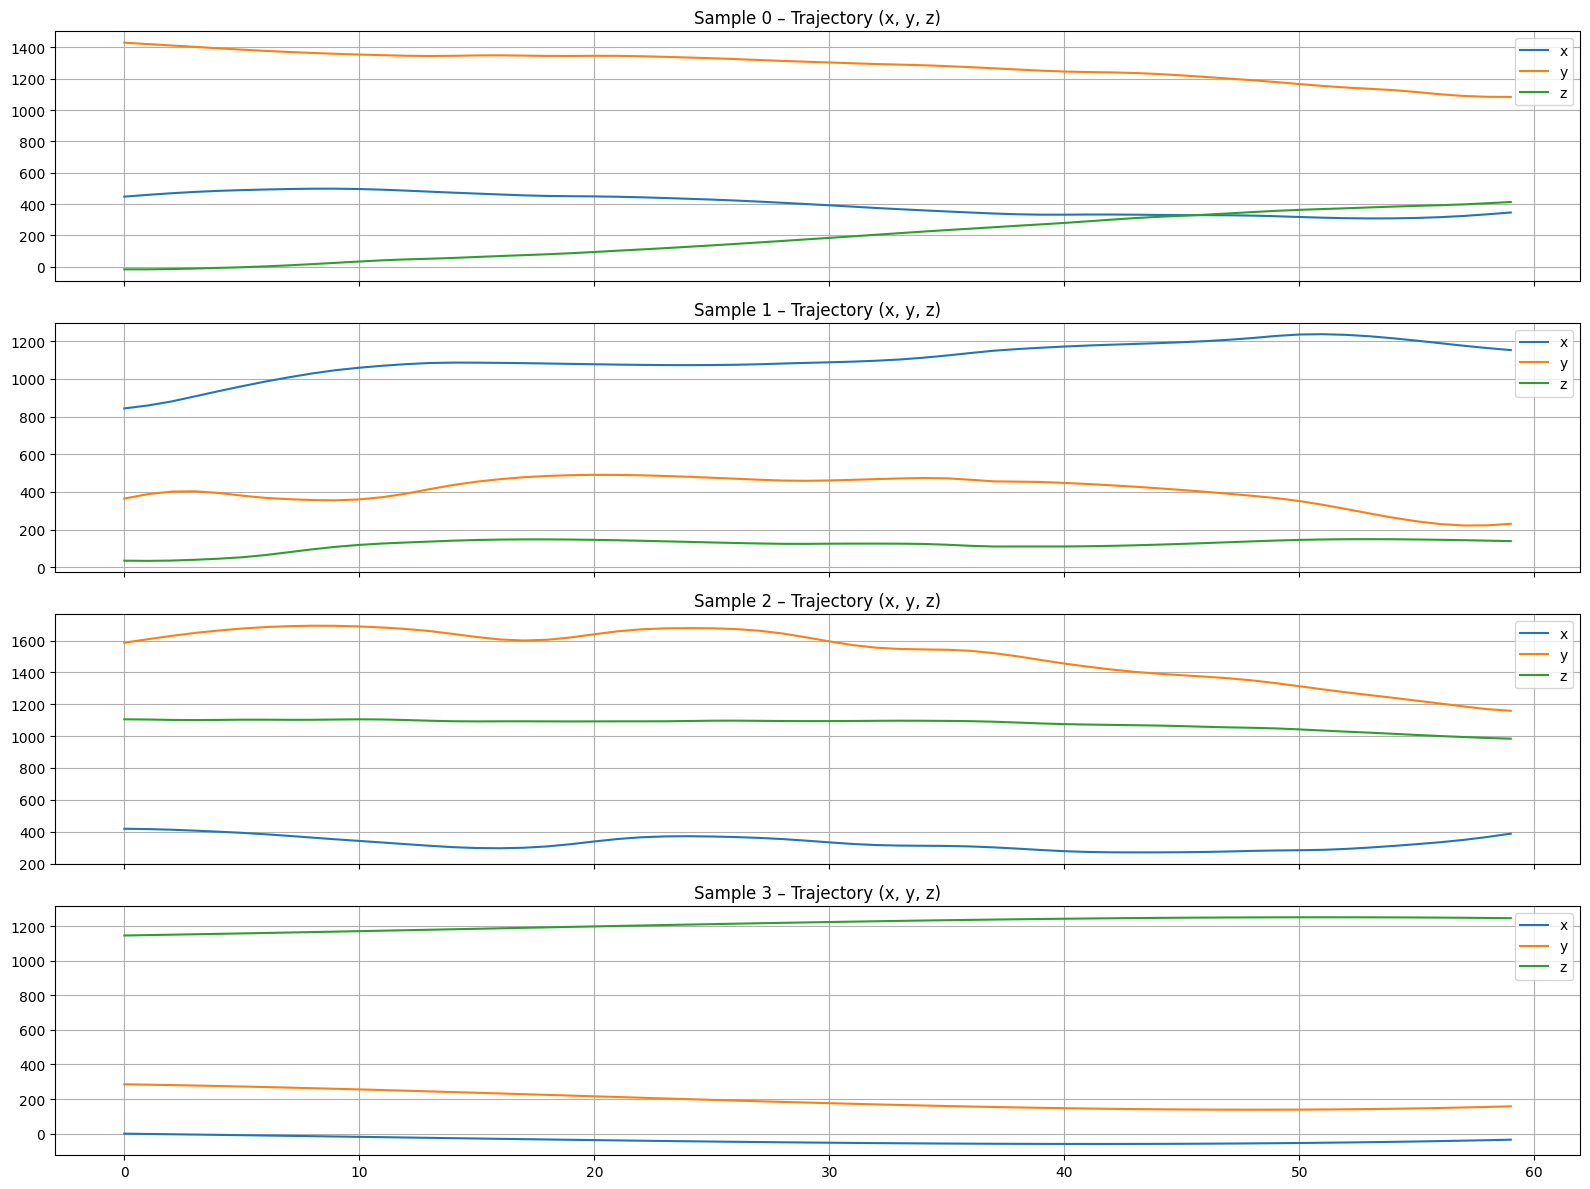

In [ ]:
# --------------------------
# Step 1: Segment Data with 0.5s Gap Threshold
# --------------------------


# in this first step we are going to divdie the whole data or trajectory we have of the bee into min with 0.5s 

#defining fucntion for segmentation
def segment_bee_data(df_bee, gap_threshold, features, min_length):
    
    df_bee = df_bee.sort_values('time').dropna(subset=features + ['time'])
    segments = []
    current = [0]
    for i in range(1, len(df_bee)):
        if df_bee['time'].iloc[i] - df_bee['time'].iloc[i - 1] <= gap_threshold:
            current.append(i)
        else:
            if len(current) >= min_length:
                segment = df_bee.iloc[current][features].to_numpy().T  # (n_features, segment_length)
                segments.append(segment)
            current = [i]
    if len(current) >= min_length:
        segment = df_bee.iloc[current][features].to_numpy().T
        segments.append(segment)
    return segments


# -- PARAMETERS --
features = ['x', 'y', 'z', 'velocityX', 'velocityY', 'velocityZ', 'tort_Xy', 'tort_Xz']
estimated_gap = 0.5  # seconds
dt = 1 / 30
min_length = 60      # keep segments of at least 2 second


df_merged=pd.read_csv('processed_bee_data.csv')


# -- SEGMENTATION --
all_segments = []
for bee in df_merged['bee_id'].unique():
    df_bee = df_merged[df_merged['bee_id'] == bee]
    segments = segment_bee_data(df_bee, estimated_gap, features, min_length)
    all_segments.extend(segments)

print(f"Extracted {len(all_segments)} segments with 0.5 threshold")


# --------------------------
# Step 2: Extract Fixed-Length Samples (2s = 60 frames)
# --------------------------



# now we are going to extract exact 2s worth of the trajectory from those segments we got earlier

fixed_length = 60
sampled_segments = []

for segment in all_segments:
    n_features, T = segment.shape
    if T < fixed_length:
        continue
    # Sliding window: all valid samples from this segment
    stride=15
    for start in range(0, T - fixed_length + 1,stride):
        sample = segment[:, start:start + fixed_length]
        sampled_segments.append(sample)

print(f"Total samples extracted: {len(sampled_segments)}")


# --------------------------
# Step 3: Inspect One Sample
# --------------------------


feature_names = features
sample = sampled_segments[0]
sample_df = pd.DataFrame(sample.T, columns=feature_names)
print("Inspecting one sample:\n")
print(sample_df.head())


# --------------------------
# Step 4: Plot All Features of One Sample
# --------------------------



plt.figure(figsize=(14, 6))
for i, feature in enumerate(feature_names):
    plt.plot(sample[i], label=feature)

plt.title("One Sample: All 8 Features Across 60 Time Steps")
plt.xlabel("Time step")
plt.ylabel("Feature value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# --------------------------
# Step 5: Feature Distribution Visualization
# --------------------------

samples_array = np.stack(sampled_segments, axis=0)  # (n_samples, n_features, window_length)

fig, axs = plt.subplots(2, 4, figsize=(18, 8))
axs = axs.flatten()

for i in range(8):
    flat_values = samples_array[:, i, :].flatten()
    axs[i].hist(flat_values, bins=100, alpha=0.7)
    axs[i].set_title(f'{feature_names[i]} Distribution')
    axs[i].set_xlabel('Value')
    axs[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


# --------------------------
# Step 6: Normalization Stats: saved
# --------------------------


# the need for normalisation is very necessary here cause the scale of the features are different hence we need to normalise them before we save them as a tensor
means = samples_array.mean(axis=(0, 2))
stds = samples_array.std(axis=(0, 2))

# ---: Save normalization stats alongside your tensor
norm_stats = {'feature_names': feature_names, 'mean': means, 'std': stds}
import pickle
with open("bee_norm_stats.pkl", "wb") as f:
    pickle.dump(norm_stats, f)
print("Saved normalization stats to bee_norm_stats.pkl")

for i in range(8):
    print(f"{feature_names[i]}: mean = {means[i]:.4f}, std = {stds[i]:.4f}")


# --------------------------
# Step 7: Save to PyTorch Tensor
# --------------------------

import torch

tensor_data = torch.tensor(samples_array, dtype=torch.float32)
torch.save(tensor_data, 'bee_segments_tensor.pt')
print(f"Saved tensor shape: {tensor_data.shape}")




# --------------------------
# Step 8: Dataset & Visualization
# --------------------------


import random
from torch.utils.data import Dataset

# Load full tensor (adjust path as needed)
bee_tensor = torch.load("bee_segments_tensor.pt")  # Your actual path

# Sample a subset for speed/experimentation
subset_size = min(1000, bee_tensor.shape[0])
indices = random.sample(range(bee_tensor.shape[0]), subset_size)
tensor_subset = bee_tensor[indices]

# Dataset class for PyTorch
class BeeTrajectoryDataset(Dataset):
    def __init__(self, data_tensor):
        self.data = data_tensor

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data[idx]

dataset = BeeTrajectoryDataset(tensor_subset)

# Plot 4 random samples (x, y, z only)
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
features_xyz = ['x', 'y', 'z']

for i in range(4):
    sample = dataset[random.randint(0, len(dataset)-1)]
    for j in range(3):  # x, y, z
        axes[i].plot(sample[j].numpy(), label=features_xyz[j])
    axes[i].legend()
    axes[i].grid(True)
    axes[i].set_title(f"Sample {i} – Trajectory (x, y, z)")

plt.tight_layout()
plt.show()

In [3]:
segment.shape

(8, 4386)

In [4]:
print(len(dataset))

1000


In [5]:
sample.shape

torch.Size([8, 60])

In [9]:
feature_names = ['x', 'y', 'z', 'velocityX', 'velocityY', 'velocityZ', 'tort_Xy', 'tort_Xz']
sample_df = pd.DataFrame(sample.numpy().T, columns=feature_names)
print(sample_df.head())

          x           y            z  velocityX  velocityY  velocityZ  \
0 -0.242699  285.382324  1145.910645 -50.180000 -63.720001  67.379997   
1 -1.939503  283.155914  1148.190063 -51.560001 -69.709999  69.309998   
2 -3.679974  280.735107  1150.531616 -52.799999 -75.379997  71.120003   
3 -5.459807  278.130249  1152.931152 -53.919998 -80.750000  72.790001   
4 -7.274701  275.351715  1155.384155 -54.910000 -85.809998  74.330002   

   tort_Xy  tort_Xz  
0      1.0      1.0  
1      1.0      1.0  
2      1.0      1.0  
3      1.0      1.0  
4      1.0      1.0  


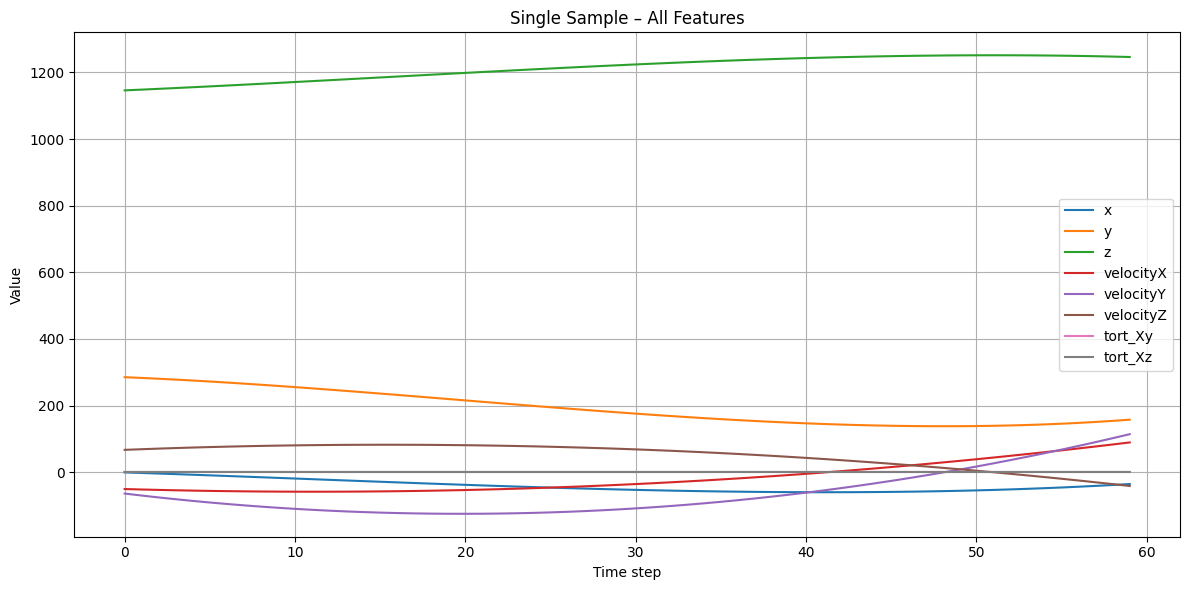

In [10]:
plt.figure(figsize=(12, 6))
for i in range(sample.shape[0]):
    plt.plot(sample[i], label=feature_names[i])
plt.legend()
plt.title("Single Sample – All Features")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid(True)
plt.tight_layout()
plt.show()



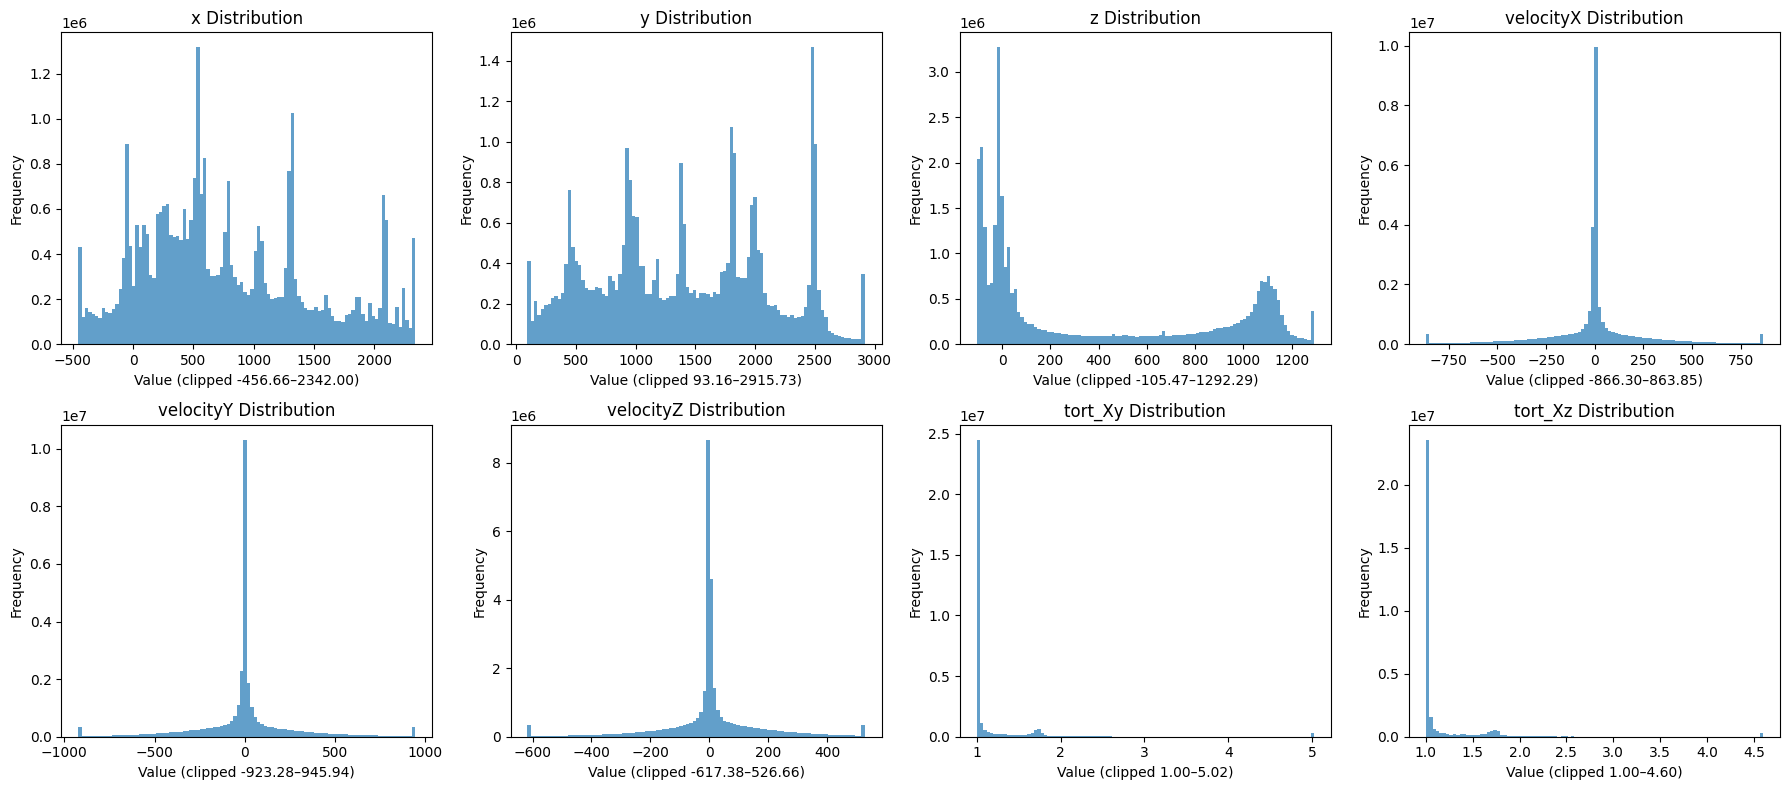

In [ ]:


fig, axs = plt.subplots(2, 4, figsize=(18, 8))
axs = axs.flatten()

for i in range(8):
    flat_values = samples_array[:, i, :].flatten()
    flat_values = flat_values[~np.isnan(flat_values)]  # Remove NaNs

    # Clip values to 1st–99th percentile to remove outliers
    lower = np.percentile(flat_values, 1)
    upper = np.percentile(flat_values, 99)
    clipped_values = np.clip(flat_values, lower, upper)

    axs[i].hist(clipped_values, bins=100, alpha=0.7)
    axs[i].set_title(f'{feature_names[i]} Distribution')
    axs[i].set_xlabel(f'Value (clipped {lower:.2f}–{upper:.2f})')
    axs[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [14]:
print("Total training samples:", bee_tensor.shape[0])


Total training samples: 540278


In [16]:
print("Shape of bee_tensor:", bee_tensor.shape)


Shape of bee_tensor: torch.Size([540278, 8, 60])


Below are the initial testing done for the model,  we will see in the next notebook which model we finalised

In [17]:

import pickle
import time

# --------------------------
# Step 1: Load Preprocessed Samples and Normalization Stats
# --------------------------

print("Loading sampled segments and normalization stats...")

# we already have `sampled_segments` in memory
samples_array = np.stack(sampled_segments, axis=0)  # Shape: (n_samples, n_features, sequence_length)
print(f"Raw sample array shape: {samples_array.shape}")

# Load previously saved mean and std
with open("bee_norm_stats.pkl", "rb") as f:
    norm_stats = pickle.load(f)

means = norm_stats["mean"]
stds = norm_stats["std"]
print("Loaded normalization stats.")

# Normalize samples using precomputed statistics
samples_array = (samples_array - means[:, None]) / stds[:, None]
print("Data normalized.")

# --------------------------
# Step 2: Convert to Tensor and Save
# --------------------------

tensor_data = torch.tensor(samples_array, dtype=torch.float32)
torch.save(tensor_data, 'bee_segments_tensor.pt')
print(f"Tensor saved with shape: {tensor_data.shape}")
print(f"Total training samples: {tensor_data.shape[0]}")

# --------------------------
# Step 3: Dataset Class
# --------------------------

class BeeTrajectoryDataset(Dataset):
    def __init__(self, data_tensor):
        self.data = data_tensor

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data[idx]

dataset = BeeTrajectoryDataset(tensor_data)

# --------------------------
# Step 4: Define 1D CNN Autoencoder
# --------------------------

class BeeAutoencoder(nn.Module):
    def __init__(self):
        super(BeeAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 8, kernel_size=3, padding=1),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# --------------------------
# Step 5: Training Setup
# --------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BeeAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

batch_size = 64
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print("\n--- Training Setup ---")
print(f"Device: {device}")
print(f"Batch size: {batch_size}")
print(f"Number of batches per epoch: {len(train_loader)}")
print("----------------------\n")

# --------------------------
# Step 6: Training Loop
# --------------------------

n_epochs = 20
epoch_times = []

print("Starting training...\n")
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    start_time = time.time()

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        output = model(batch)
        loss = criterion(output, batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    end_time = time.time()
    epoch_duration = end_time - start_time
    epoch_times.append(epoch_duration)
    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1:02d}/{n_epochs}, Loss: {avg_loss:.4f}, Time: {epoch_duration:.2f} sec")

# --------------------------
# Step 7: Save the Trained Model
# --------------------------

torch.save(model.state_dict(), "bee_autoencoder.pth")
print("\nModel training complete.")
print("Saved model to 'bee_autoencoder.pth'.")

# --------------------------
# Summary
# --------------------------

print("\n--- Training Summary ---")
print(f"Total samples used: {len(dataset)}")
print(f"Final loss: {avg_loss:.4f}")
print(f"Average epoch duration: {np.mean(epoch_times):.2f} seconds")
print("-------------------------")


Loading sampled segments and normalization stats...
Raw sample array shape: (540278, 8, 60)
Loaded normalization stats.
Data normalized.
Tensor saved with shape: torch.Size([540278, 8, 60])
Total training samples: 540278

--- Training Setup ---
Device: cpu
Batch size: 64
Number of batches per epoch: 8442
----------------------

Starting training...

Epoch 01/20, Loss: 0.2625, Time: 78.44 sec
Epoch 02/20, Loss: 0.2198, Time: 78.54 sec
Epoch 03/20, Loss: 0.2431, Time: 77.85 sec
Epoch 04/20, Loss: 0.1401, Time: 72.80 sec
Epoch 05/20, Loss: 0.1575, Time: 73.95 sec
Epoch 06/20, Loss: 0.1633, Time: 74.94 sec
Epoch 07/20, Loss: 0.1869, Time: 70.40 sec
Epoch 08/20, Loss: 0.1087, Time: 76.43 sec
Epoch 09/20, Loss: 0.1325, Time: 72.77 sec
Epoch 10/20, Loss: 0.1116, Time: 79.16 sec
Epoch 11/20, Loss: 0.1148, Time: 80.86 sec
Epoch 12/20, Loss: 0.0837, Time: 78.11 sec
Epoch 13/20, Loss: 0.2201, Time: 78.22 sec
Epoch 14/20, Loss: 0.0967, Time: 67.16 sec
Epoch 15/20, Loss: 0.1077, Time: 78.41 sec
Epo

We calculated the MSE per feature for analysis and also we reconstructed the input with respect to output to visually inspect how well the model is working


--- MSE per Feature on Validation Set ---
x: MSE = 0.001887
y: MSE = 0.002008
z: MSE = 0.001699
velocityX: MSE = 0.003393
velocityY: MSE = 0.008103
velocityZ: MSE = 0.004215
tort_Xy: MSE = 0.000607
tort_Xz: MSE = 0.000563
------------------------------------------


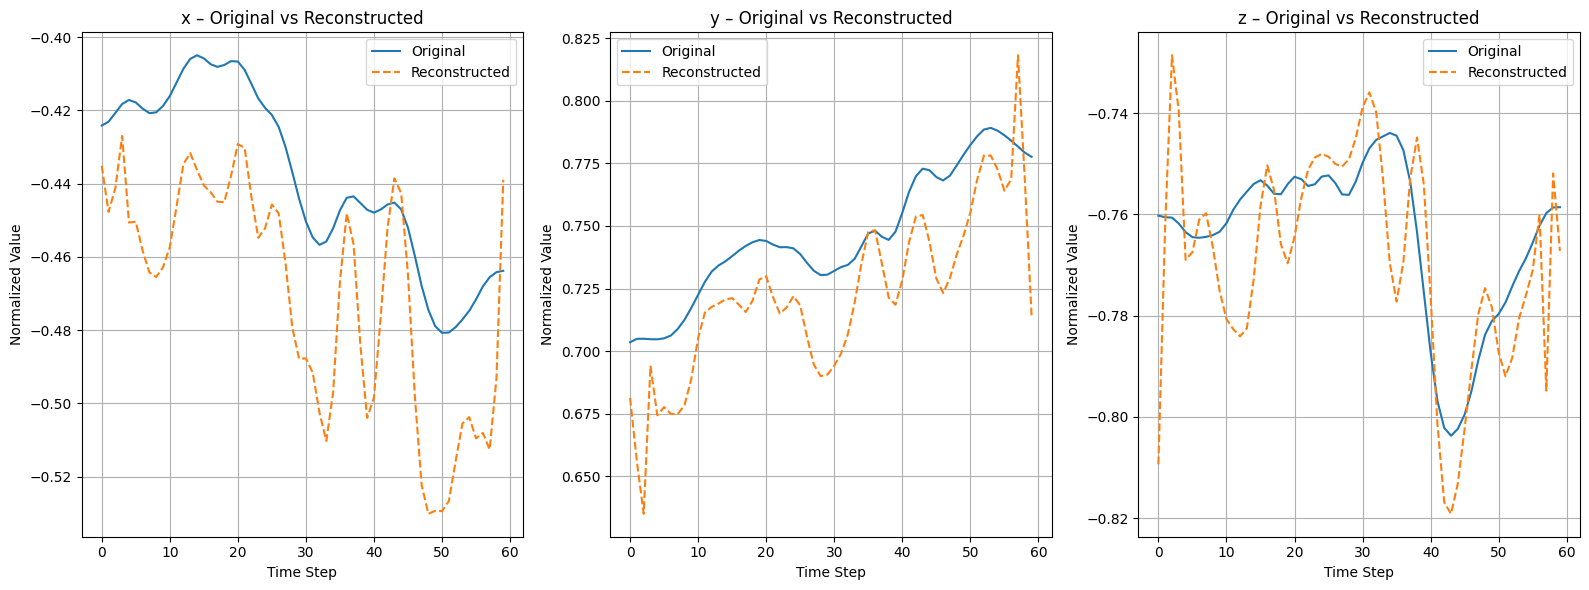

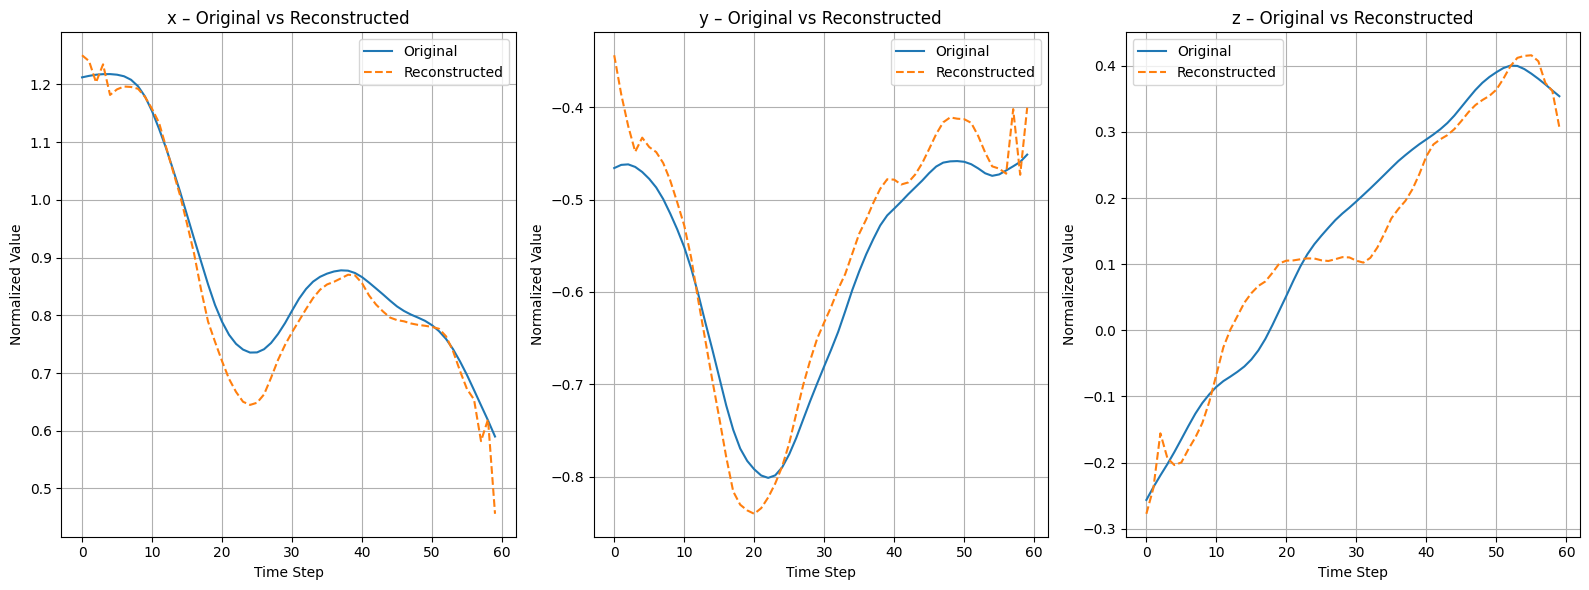

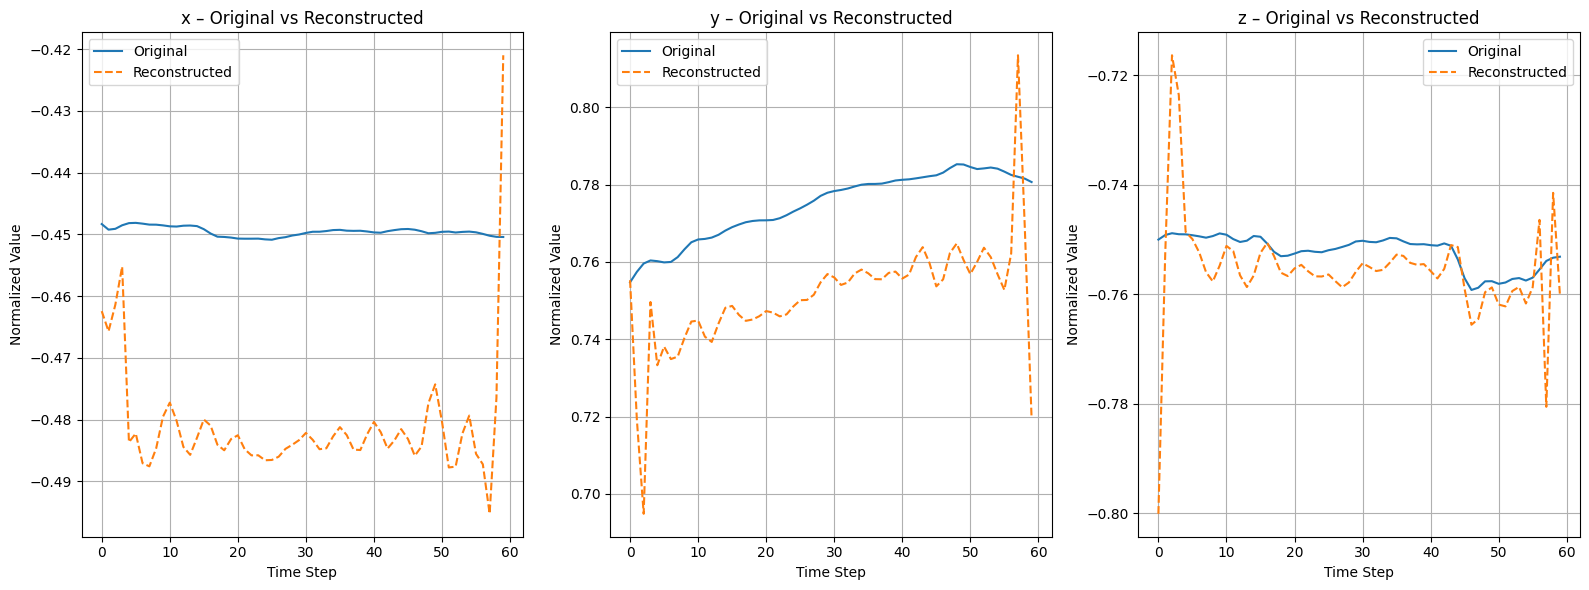

In [18]:


# --------------------------
# Step 1: Load Data & Model
# --------------------------

# Load full normalized tensor
bee_tensor = torch.load("bee_segments_tensor.pt")  # shape: (540278, 8, 60)

# Load trained model
class BeeAutoencoder(torch.nn.Module):
    def __init__(self):
        super(BeeAutoencoder, self).__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Conv1d(8, 16, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv1d(16, 32, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv1d(32, 16, kernel_size=3, padding=1),
            torch.nn.ReLU(),
        )
        self.decoder = torch.nn.Sequential(
            torch.nn.Conv1d(16, 32, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv1d(32, 16, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv1d(16, 8, kernel_size=3, padding=1),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BeeAutoencoder().to(device)
model.load_state_dict(torch.load("bee_autoencoder.pth", map_location=device))
model.eval()

# --------------------------
# Step 2: Create Validation Set
# --------------------------

val_tensor = bee_tensor[-1000:]  # Last 1000 samples
val_loader = DataLoader(val_tensor, batch_size=64, shuffle=False)

# --------------------------
# Step 3: Evaluate MSE per Feature
# --------------------------

feature_names = ['x', 'y', 'z', 'velocityX', 'velocityY', 'velocityZ', 'tort_Xy', 'tort_Xz']
mse_per_feature = np.zeros(8)
total_samples = 0

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        output = model(batch)
        diff = (output - batch) ** 2  # squared error
        mse = diff.mean(dim=2).sum(dim=0).cpu().numpy()  # average over time steps, then sum over batch
        mse_per_feature += mse
        total_samples += batch.size(0)

mse_per_feature /= total_samples

print("\n--- MSE per Feature on Validation Set ---")
for i in range(8):
    print(f"{feature_names[i]}: MSE = {mse_per_feature[i]:.6f}")
print("------------------------------------------")

# --------------------------
# Step 4: Plot Reconstructed vs Original
# --------------------------

# Select 3 random validation samples
indices = random.sample(range(val_tensor.shape[0]), 3)

for idx in indices:
    sample = val_tensor[idx].unsqueeze(0).to(device)  # shape (1, 8, 60)
    with torch.no_grad():
        recon = model(sample).squeeze(0).cpu().numpy()
    original = sample.squeeze(0).cpu().numpy()

    plt.figure(figsize=(16, 6))
    for i, feature in enumerate(['x', 'y', 'z']):
        plt.subplot(1, 3, i+1)
        plt.plot(original[i], label='Original')
        plt.plot(recon[i], label='Reconstructed', linestyle='--')
        plt.title(f'{feature} – Original vs Reconstructed')
        plt.xlabel('Time Step')
        plt.ylabel('Normalized Value')
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()


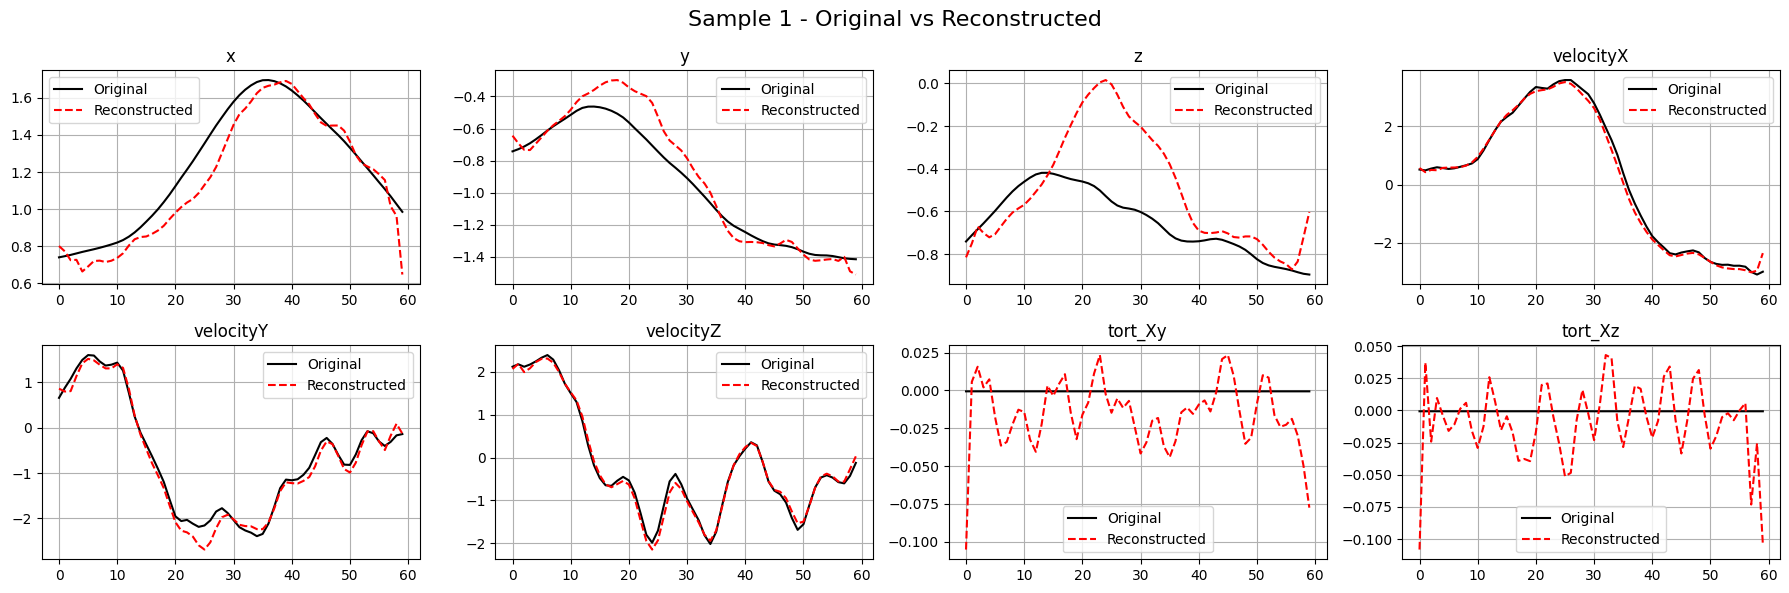

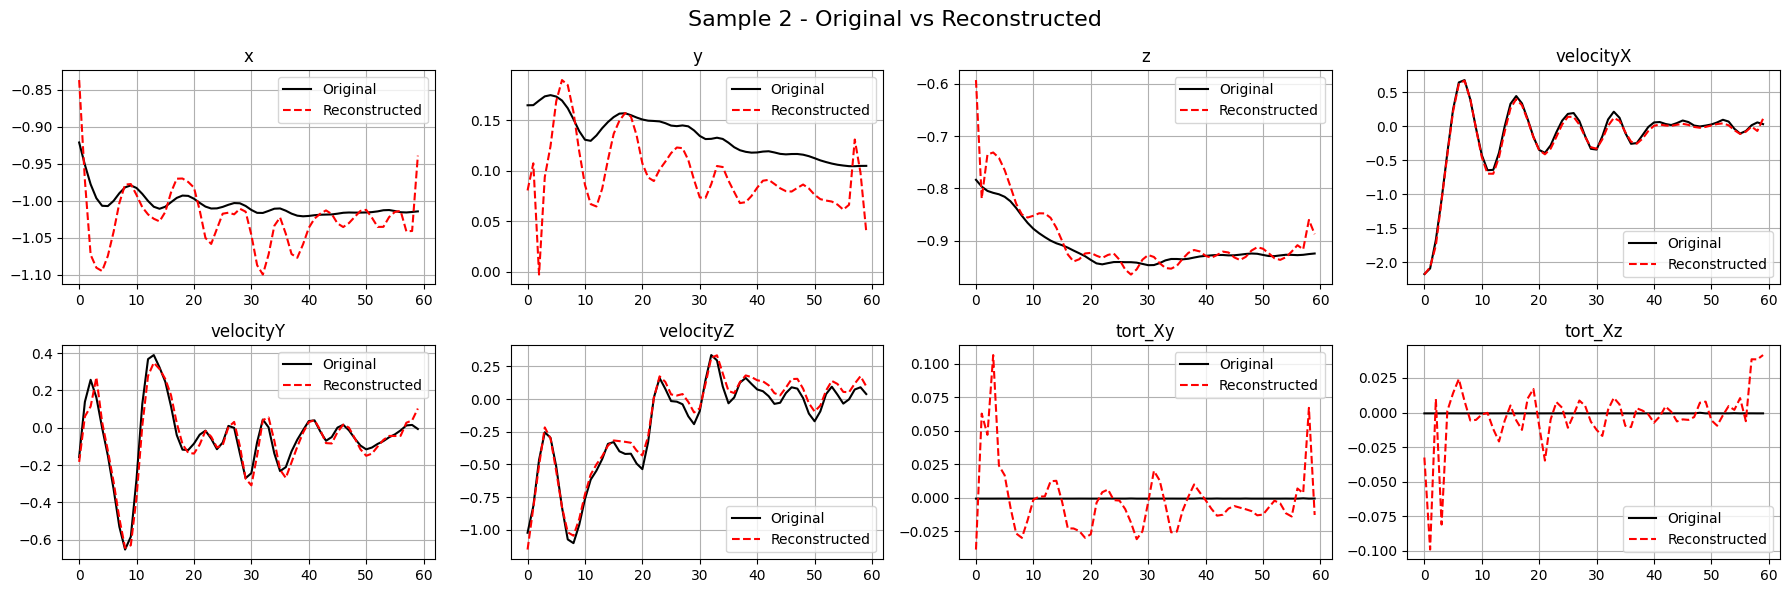

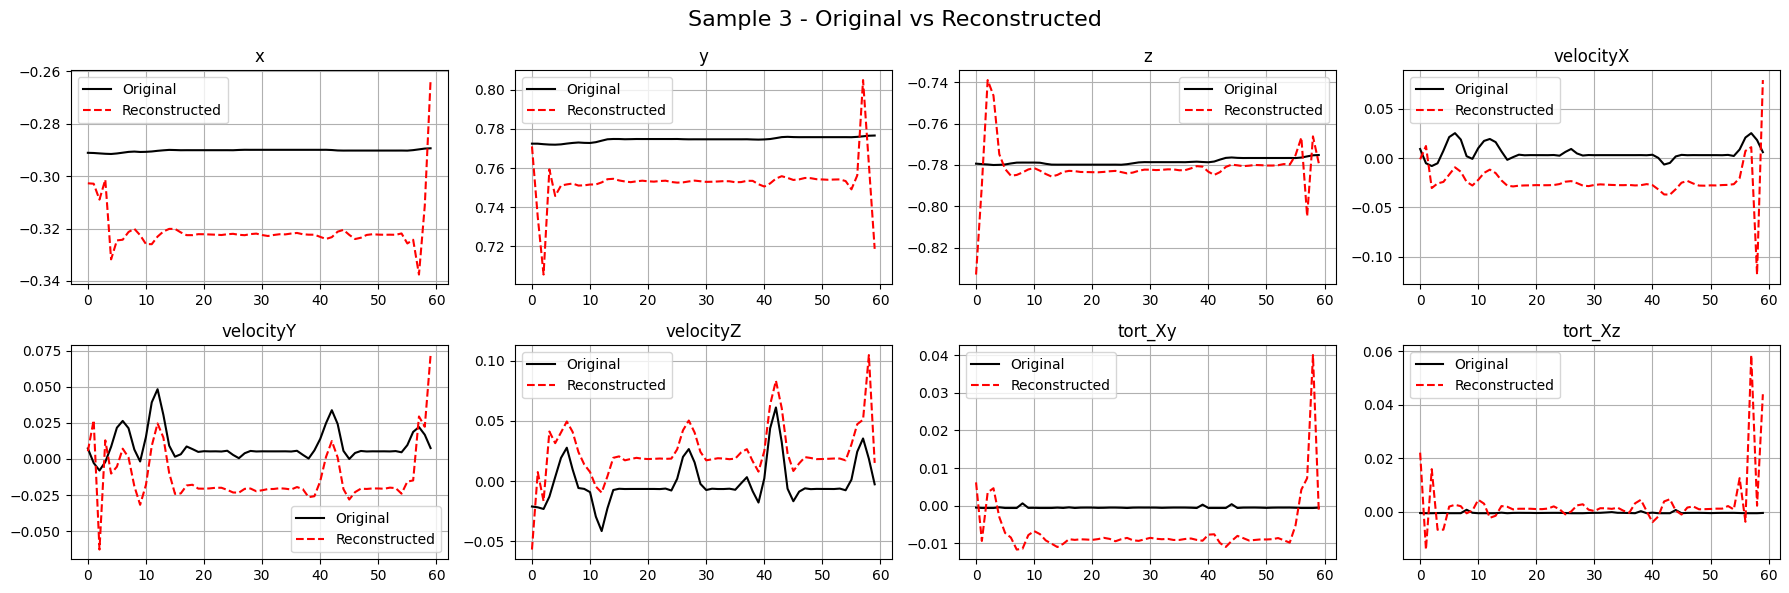

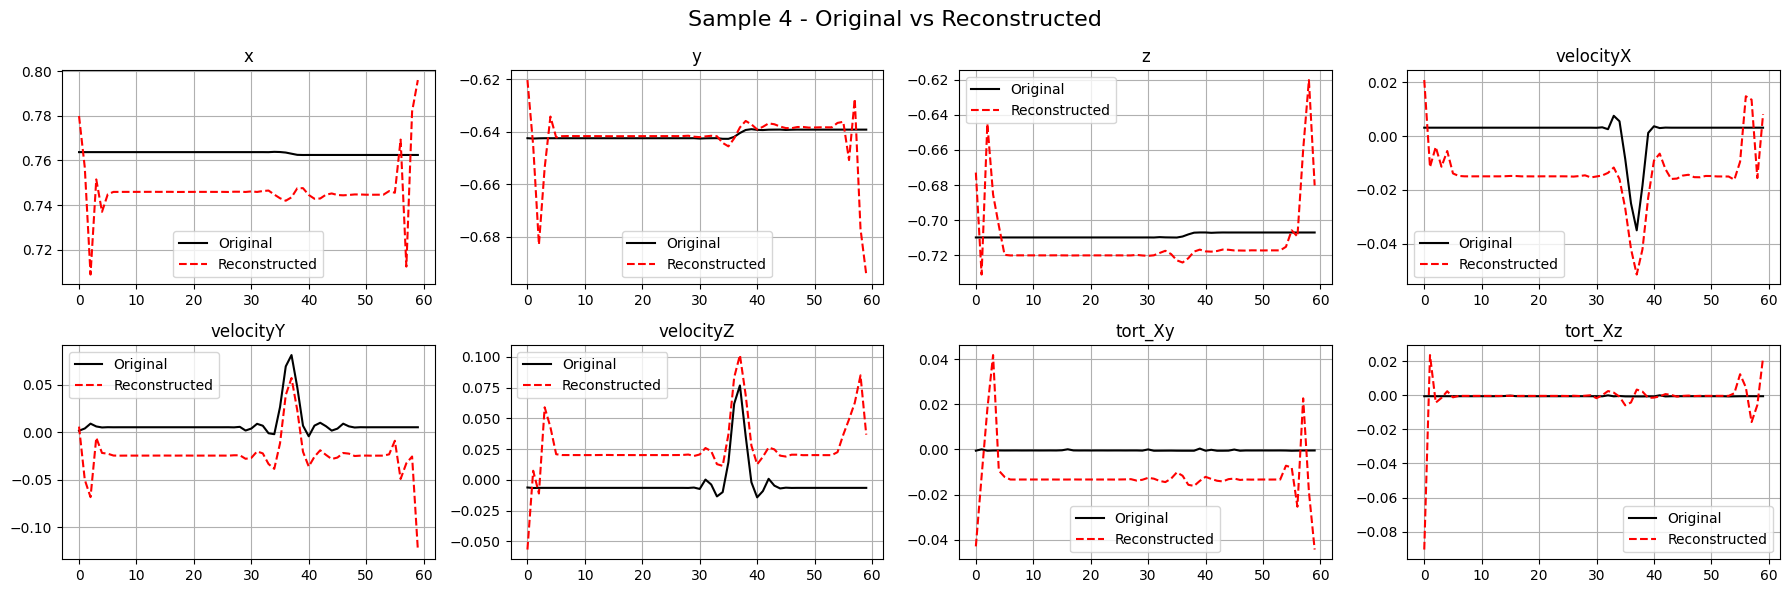

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random


# ---------------------------------------
# 1. Define the original model (same as during training)
# ---------------------------------------
class BeeAutoencoder(nn.Module):
    def __init__(self):
        super(BeeAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 8, kernel_size=3, padding=1),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# ---------------------------------------
# 2. Load model and weights
# ---------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = BeeAutoencoder().to(device)

# Load trained model
autoencoder.load_state_dict(torch.load("bee_autoencoder.pth", map_location=device))
autoencoder.eval()

# Extract encoder and decoder separately
encoder = autoencoder.encoder
decoder = autoencoder.decoder

# ---------------------------------------
# 3. Load unnormalized data
# ---------------------------------------
data_tensor = torch.load("bee_segments_tensor.pt")  # Should be unnormalized
feature_names = ['x', 'y', 'z', 'velocityX', 'velocityY', 'velocityZ', 'tort_Xy', 'tort_Xz']

# Sample 4 random examples
samples = data_tensor[random.sample(range(len(data_tensor)), 4)]

# ---------------------------------------
# 4. Plot raw vs reconstructed (unnormalized)
# ---------------------------------------
with torch.no_grad():
    reconstructed = autoencoder(samples.to(device)).cpu()

# Plot
for i in range(4):
    fig, axs = plt.subplots(2, 4, figsize=(18, 6))
    axs = axs.flatten()

    for j in range(8):
        axs[j].plot(samples[i][j].numpy(), label='Original', color='black')
        axs[j].plot(reconstructed[i][j].numpy(), label='Reconstructed', linestyle='--', color='red')
        axs[j].set_title(feature_names[j])
        axs[j].legend()
        axs[j].grid(True)

    plt.suptitle(f"Sample {i+1} - Original vs Reconstructed", fontsize=16)
    plt.tight_layout()
    plt.show()
